<a href="https://colab.research.google.com/github/fdac25/MP2/blob/main/Vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt



In [6]:
df = pd.read_csv(
    "bjy819_project_summary.csv",
    sep=";",
    keep_default_na=False
)

df = df.rename(columns={
    "project_wocid": "project",
    "commit_sha1": "commit",
    "commit message": "message"
})

df["Month"] = pd.to_datetime(
    df["time"], unit="s", utc=True
).dt.strftime("%Y-%m")

df.head()

,project,commit,author,time,message,Month
0,mobvoi_wenet,00068789555dbe4c6aff671288cb40ead8bf9105,Binbin Zhang <binbzha@qq.com>,1651152697,[binding]: add python binding\n,2022-04
1,mobvoi_wenet,000c7af5c36afafd3fa3ae4599af237e902c67bb,Mddct <hamddct@gmail.com>,1697436927,[cli/paraformer] ali-paraformer load and inf...,2023-10
2,mobvoi_wenet,00142a006a0845fc83e0e9b103fc9e2b1ee25420,robin1001 <robin1001@users.noreply.github.com>,1612274843,Automated deployment: Tue Feb 2 14:07:23 UTC ...,2021-02
3,mobvoi_wenet,003277de21ab47572e15e7d42d20ac8255e78fcc,Binbin Zhang <binbzha@qq.com>,1651395445,try cibuildwheel\n,2022-05
4,mobvoi_wenet,003766d4031504c1d84077211355a16896b6b6b9,zhyyao <94102052+zhyyao@users.noreply.github.com>,1657845908,[rnnt] beamsearch (#1302)\n\n* rnnt prefix bea...,2022-07


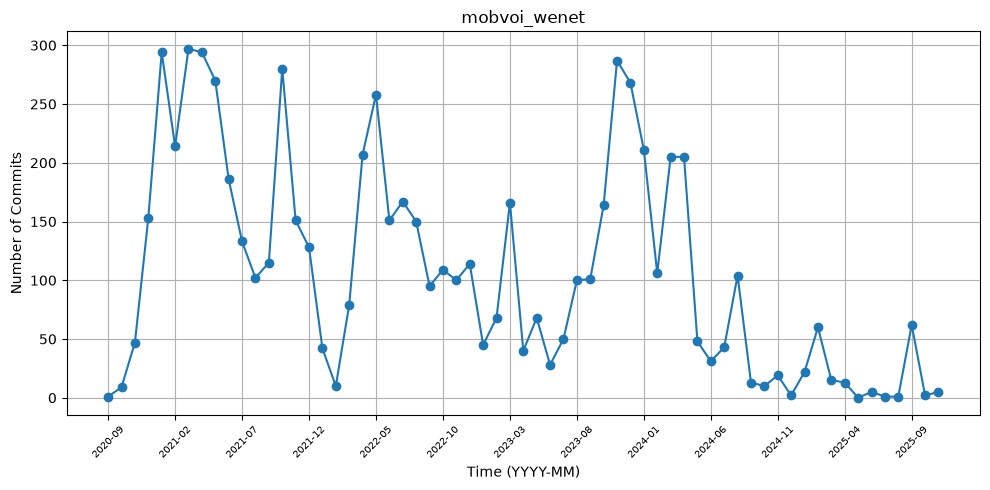

Saved monthly CSV and graph for mobvoi_wenet


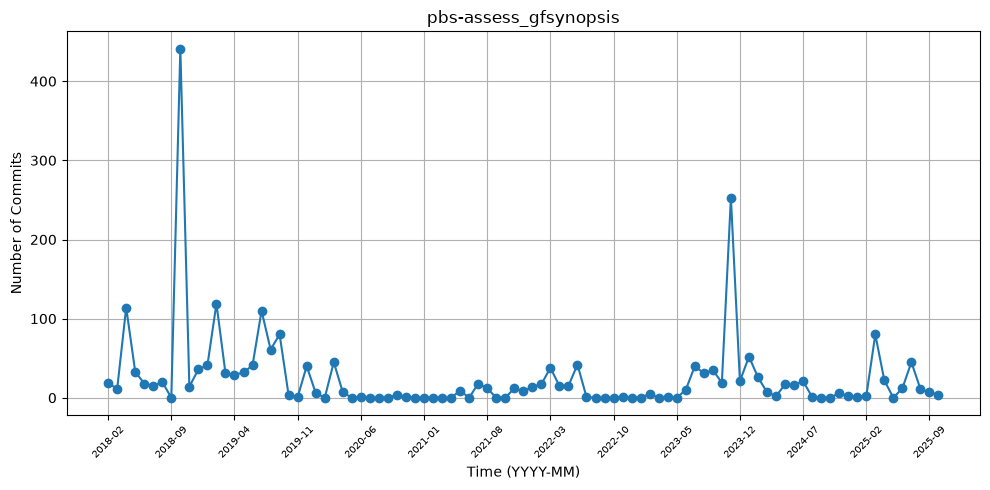

Saved monthly CSV and graph for pbs-assess_gfsynopsis


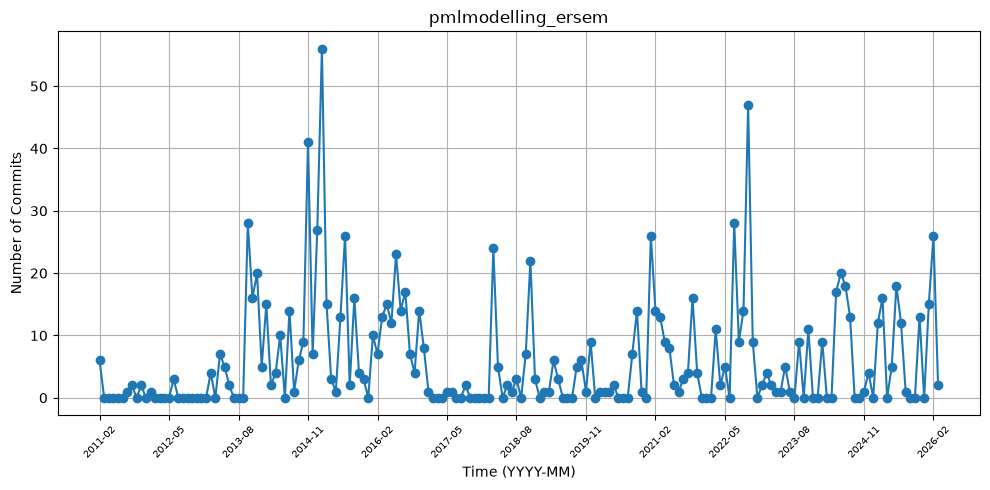

Saved monthly CSV and graph for pmlmodelling_ersem


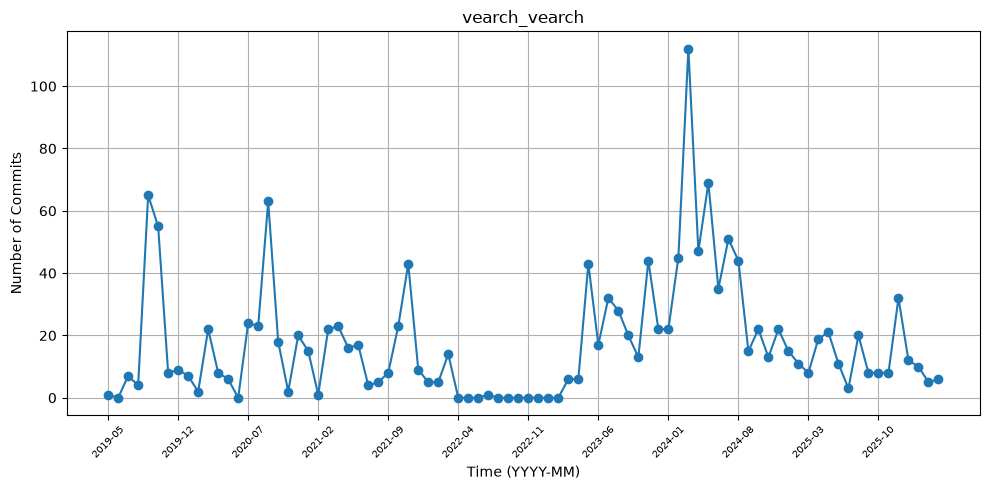

Saved monthly CSV and graph for vearch_vearch


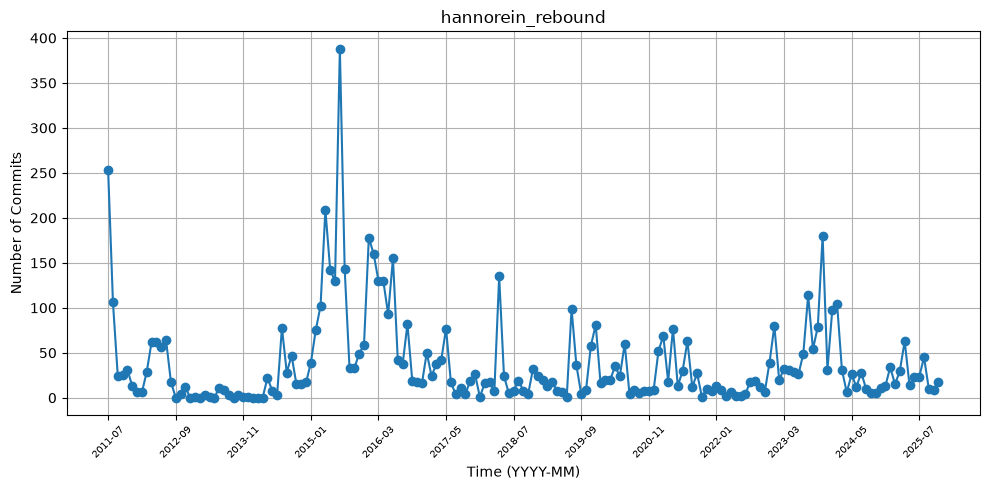

Saved monthly CSV and graph for hannorein_rebound


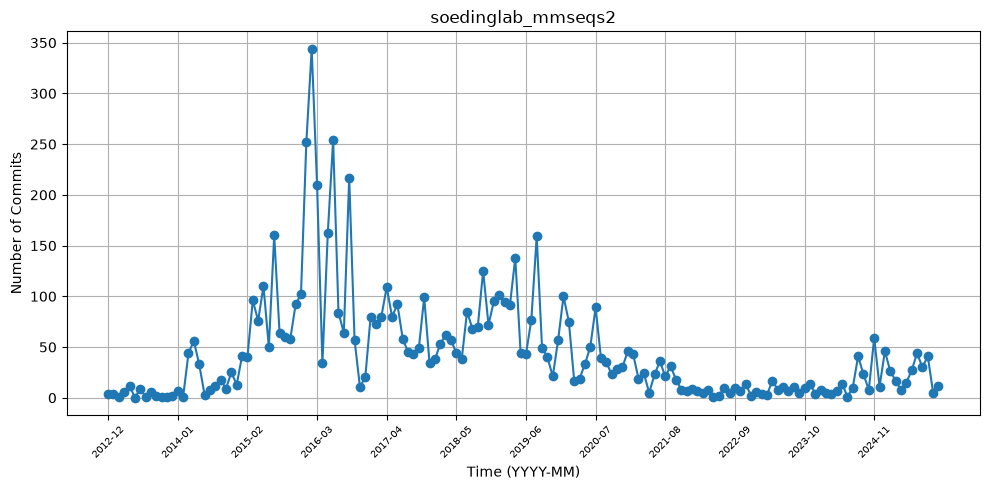

Saved monthly CSV and graph for soedinglab_mmseqs2


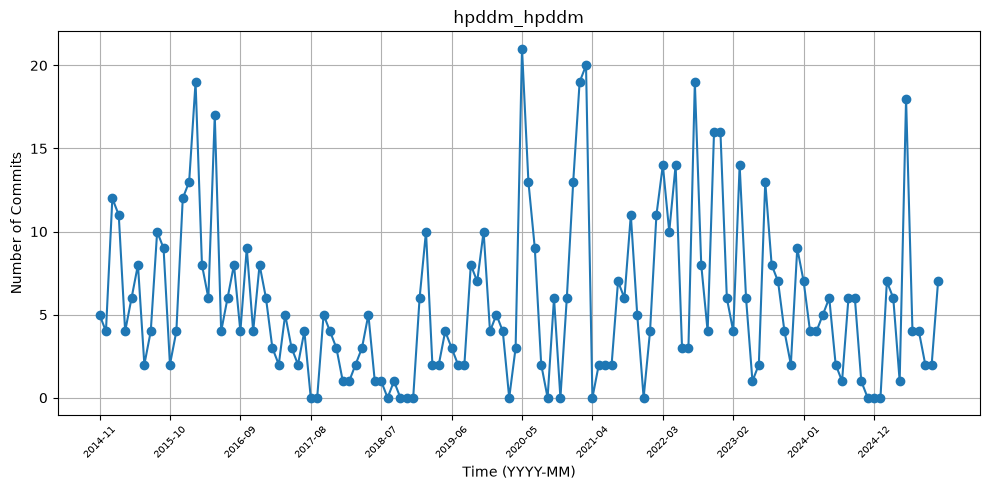

Saved monthly CSV and graph for hpddm_hpddm


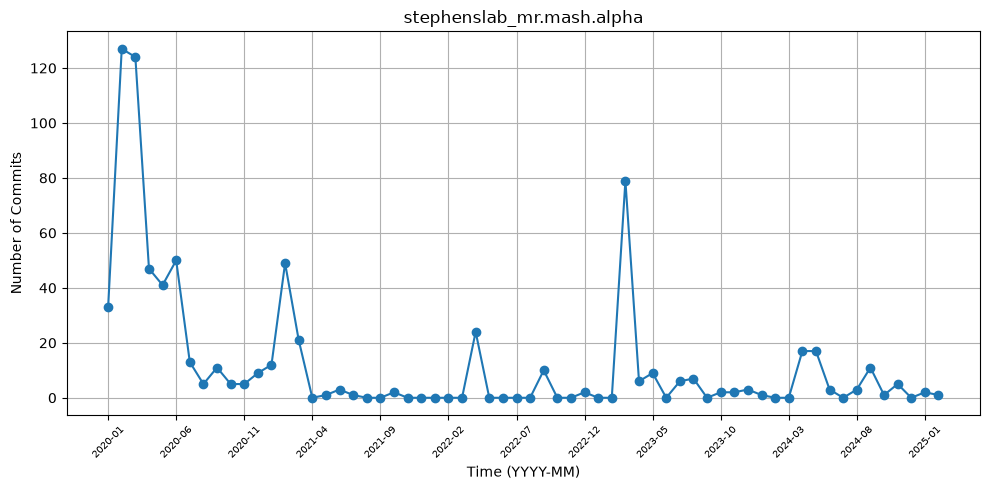

Saved monthly CSV and graph for stephenslab_mr.mash.alpha


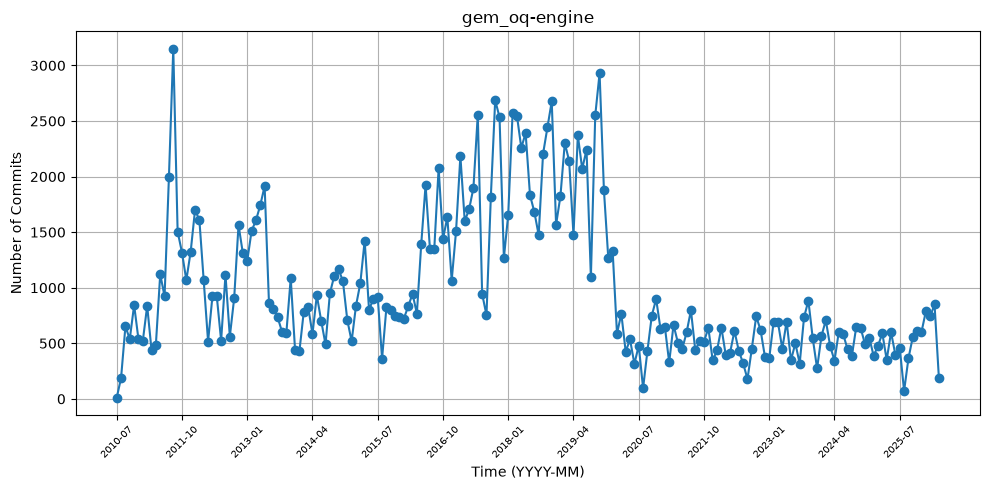

Saved monthly CSV and graph for gem_oq-engine


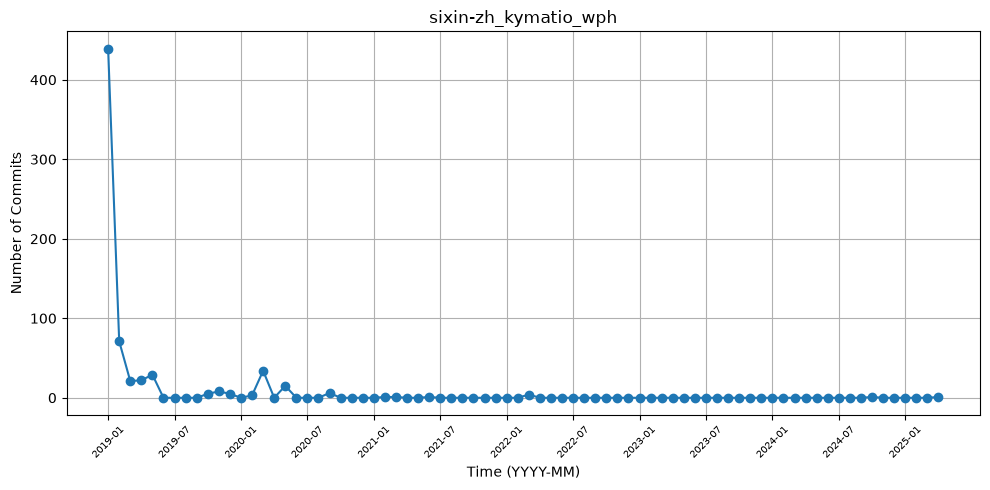

Saved monthly CSV and graph for sixin-zh_kymatio_wph


In [10]:
for prj in df["project"].unique():
    # Monthly counts — same approach as the starter
    df1 = df[df["project"] == prj]
    df2 = df1.groupby("Month").size().reset_index(name="Commits")
    monthly_counts = df2.copy()

    monthly_counts["time"] = pd.to_datetime(monthly_counts["Month"])

    full_date_range = pd.DataFrame({
        "time": pd.date_range(
            start=monthly_counts["time"].min(),
            end=monthly_counts["time"].max(),
            freq="MS"
        )
    })

    monthly_counts = pd.merge(
        full_date_range, monthly_counts, on="time", how="left"
    )

    monthly_counts["Commits"] = (
        monthly_counts["Commits"].fillna(0).astype(int)
    )
    monthly_counts["Month"] = (
        monthly_counts["time"].dt.strftime("%Y-%m")
    )

    # Save the required two-column monthly CSV
    monthly_counts[["Month", "Commits"]].rename(
        columns={"Commits": "#Commits"}
    ).to_csv(
        "bjy819_commits_timeseries_" + prj + ".csv",
        sep=";",
        index=False
    )

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(
        monthly_counts["Month"],
        monthly_counts["Commits"],
        marker="o",
        linestyle="-"
    )
    plt.xlabel("Time (YYYY-MM)")
    plt.ylabel("Number of Commits")
    plt.title(prj)
    plt.grid(True)

    # Show approximately 12 date labels for readability
    step = max(1, len(monthly_counts) // 12)
    plt.xticks(
        range(0, len(monthly_counts), step),
        monthly_counts["Month"].iloc[::step],
        rotation=45,
        fontsize=7
    )

    plt.tight_layout()
    plt.savefig("bjy819_timeseries_" + prj + ".png", dpi=600)
    plt.show()
    plt.close()

    print(f"Saved monthly CSV and graph for {prj}")


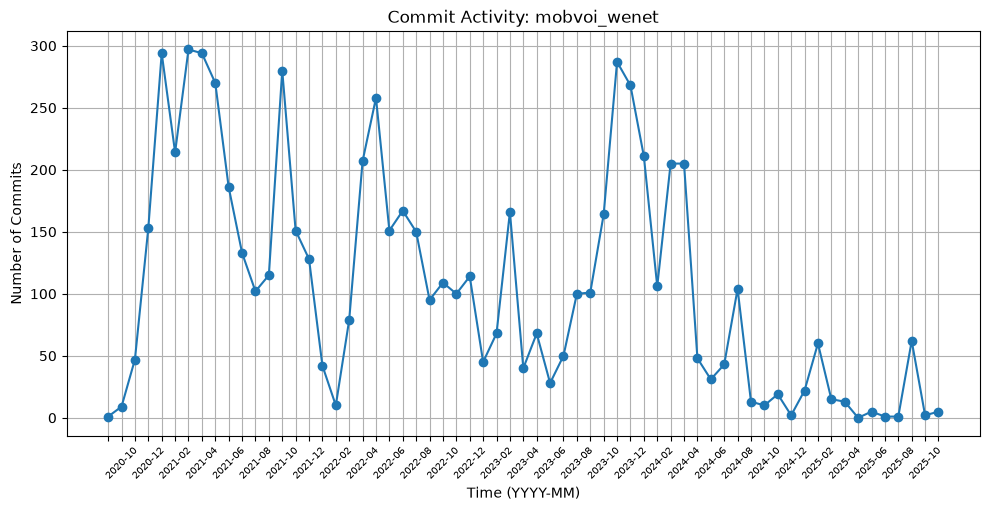

In [9]:
# Plot
import matplotlib.ticker as ticker

plt.figure(figsize=(10,5))
plt.plot(monthly_counts["Month"], monthly_counts["Commits"], marker="o", linestyle="-")
plt.xlabel("Time (YYYY-MM)")
plt.ylabel("Number of Commits")
plt.title("Commit Activity: "+prj)
plt.grid(True)
plt.tight_layout()
ax =  plt.gca()
for label in ax.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
plt.xticks(rotation=45, fontsize=7)
plt.savefig("your-net-id-here_timeseries_"+prj+".png", dpi=600)
plt.show()
plt.close()

# Identify the Longest Inactivity Gap



In [12]:
github = pd.DataFrame([
    ["mobvoi_wenet", 5243, 1190, "2026-09-07T07:21:08Z"],
    ["pbs-assess_gfsynopsis", 17, 1, "2026-09-19T23:19:56Z"],
    ["pmlmodelling_ersem", 30, 14, "2026-08-18T13:51:19Z"],
    ["vearch_vearch", 2331, 365, "2026-07-27T05:29:53Z"],
    ["hannorein_rebound", 1138, 270, "2026-10-06T12:13:52Z"],
    ["soedinglab_mmseqs2", 2148, 303, "2026-09-30T04:36:10Z"],
    ["hpddm_hpddm", 160, 37, "2026-09-26T19:46:30Z"],
    ["stephenslab_mr.mash.alpha", 7, 5, "2026-02-16T16:00:01Z"],
    ["gem_oq-engine", 451, 325, "2026-10-08T02:09:51Z"],
    ["sixin-zh_kymatio_wph", 0, 0, "2025-04-10T14:37:11Z"],
], columns=["Project", "nstars", "nforks", "lastGHCommitDate"])

# These values were collected on October 8, 2026 (UTC).
github.to_csv(
    "bjy819_github_metadata.csv",
    sep=";",
    index=False
)

print("Saved GitHub metadata for", len(github), "projects.")

Saved GitHub metadata for 10 projects.


In [ ]:
github = pd.read_csv("bjy819_github_metadata.csv", sep=";")
project_stats = []

for prj in df["project"].unique():
    monthly = pd.read_csv(
        f"commits_timeseries/bjy819_commits_timeseries_{prj}.csv",
    sep=";"
    ).sort_values("Month").reset_index(drop=True)

    gaps = []
    gap_start = None

    for i, count in enumerate(monthly["#Commits"]):
        if count == 0:
            if gap_start is None:
                gap_start = i
        elif gap_start is not None:
            gaps.append((gap_start, i - 1))
            gap_start = None

    # Handle a gap reaching the last row, if present
    if gap_start is not None:
        gaps.append((gap_start, len(monthly) - 1))

    if gaps:
        # For ties, choose the earliest longest gap
        start, end = max(gaps, key=lambda gap: gap[1] - gap[0] + 1)

        longest_start = monthly.loc[start, "Month"]
        longest_end = monthly.loc[end, "Month"]
        longest_length = end - start + 1
        commits_after = int(monthly.loc[end + 1:, "#Commits"].sum())
    else:
        longest_start = ""
        longest_end = ""
        longest_length = 0
        commits_after = pd.NA  # No gap to count after

    number_of_gaps = sum(
        end - start + 1 >= 3
        for start, end in gaps
    )

    project = df[df["project"] == prj]
    dates = pd.to_datetime(project["time"], unit="s", utc=True)

    project_stats.append({
        "Project": prj,
        "ncommits": project["commit"].nunique(),
        "nauthors": project["author"].nunique(),
        "from": dates.min().isoformat(),
        "to": dates.max().isoformat(),
        "LongestGapStart": longest_start,
        "LongestGapEnd": longest_end,
        "LongestGapLength": longest_length,
        "NumCommitsAfterLastGap": commits_after,
        "NumberOfGapsInTimeline": number_of_gaps,
        "ActivityPattern": ""
    })

stats = pd.DataFrame(project_stats)

stats = stats.merge(
    github[["Project", "nstars", "nforks", "lastGHCommitDate"]],
    on="Project",
    how="left",
    validate="one_to_one"
)

stats["NumCommitsAfterLastGap"] = (
    stats["NumCommitsAfterLastGap"].astype("Int64")
)

stats.to_csv("bjy819_project_stats.csv", sep=";", index=False)

display(stats[[
    "Project",
    "LongestGapStart",
    "LongestGapEnd",
    "LongestGapLength",
    "NumCommitsAfterLastGap",
    "NumberOfGapsInTimeline"
]])

FileNotFoundError: [Errno 2] No such file or directory: 'bjy819_commits_timeseries_mobvoi_wenet.csv'